# Bab 3: Statistical Experiments and Significance Testing

Notebook ini merangkum Bab 3 buku *Practical Statistics for Data Scientists* (Bruce, Bruce & Gedeck). Bab ini membahas bagaimana merancang eksperimen (A/B testing) dan berbagai cara menguji apakah perbedaan yang teramati itu nyata atau cuma kebetulan.

Dataset yang dipakai sama dengan buku, dari repo data resminya di `https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/`:

- `web_page_data.csv` — lama sesi pengunjung di Page A vs Page B, untuk permutation test dan t-test
- `four_sessions.csv` — lama sesi pengunjung di empat halaman, untuk ANOVA
- `click_rates.csv` — jumlah klik tiga headline berbeda, untuk chi-square test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import TTestIndPower, NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

sns.set_style("whitegrid")
pd.set_option("display.precision", 4)
rng = np.random.default_rng(42)

BASE = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

## 1. A/B Testing

**A/B test** adalah eksperimen dengan dua kelompok (atau lebih) untuk membandingkan mana yang lebih baik di antara dua perlakuan, misalnya dua desain halaman web, dua judul artikel, atau dua strategi harga. Biasanya salah satu jadi **control** (perlakuan standar/tanpa perubahan) dan yang lain jadi **treatment** (perlakuan baru yang diuji).

Prinsip pentingnya:

- Subjek (pengunjung, pelanggan, dll.) idealnya di-**randomize**, ditempatkan secara acak ke salah satu kelompok, supaya perbedaan hasil bisa diatribusikan ke perlakuan, bukan ke karakteristik subjek itu sendiri.
- Perlu ditentukan lebih dulu **metrik/statistik uji** apa yang jadi acuan keberhasilan, sebelum eksperimen berjalan, bukan mengulik data setelahnya sampai ketemu pola yang "menarik".

Bab ini menggunakan data lama sesi pengunjung (`Time`, dalam detik) di dua versi halaman web, `Page A` dan `Page B`, sebagai contoh berjalan sepanjang bab.

In [2]:
web_page_data = pd.read_csv(BASE + "web_page_data.csv")
web_page_data.head(10)

,Page,Time
0,Page A,0.21
1,Page B,2.53
2,Page A,0.35
3,Page B,0.71
4,Page A,0.67
5,Page B,0.85
6,Page A,2.11
7,Page B,2.46
8,Page A,1.32
9,Page B,1.49


In [3]:
summary = web_page_data.groupby("Page")["Time"].agg(["count", "mean", "std"])
summary

,count,mean,std
Page,,,
Page A,21,1.2633,0.8846
Page B,15,1.6200,1.0114


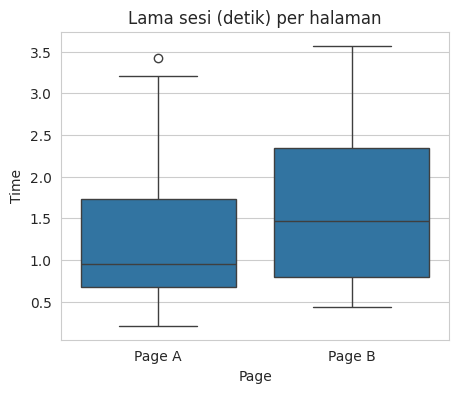

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=web_page_data, x="Page", y="Time", ax=ax)
ax.set_title("Lama sesi (detik) per halaman")
plt.show()

Page B rata-rata sedikit lebih lama dibanding Page A. Pertanyaannya: apakah selisih ini menunjukkan Page B memang lebih menarik, atau ini cuma variasi acak yang wajar terjadi walau sebenarnya kedua halaman sama saja? Ini yang akan dijawab lewat hypothesis testing di bagian berikutnya.

## 2. Hypothesis Tests

**Hypothesis test** (uji hipotesis) adalah cara formal untuk menjawab pertanyaan di atas. Dua komponen utamanya:

- **Null hypothesis (H0)**: anggapan dasar bahwa tidak ada perbedaan nyata, selisih yang teramati murni karena kebetulan/variasi acak. Misalnya, "rata-rata lama sesi Page A dan Page B sebenarnya sama".
- **Alternative hypothesis (H1)**: kebalikannya, ada perbedaan nyata (bisa satu arah atau dua arah).


## 3. Resampling: Permutation Test

Salah satu cara paling intuitif menjawab pertanyaan di atas adalah lewat **permutation test**. Idenya: kalau null hypothesis benar (label Page A/Page B tidak benar-benar berpengaruh), maka label itu seharusnya bisa ditukar-tukar secara acak tanpa mengubah pola data secara sistematis.

Langkah-langkahnya:

1. Gabungkan semua data dari kedua kelompok jadi satu kumpulan.
2. Acak (shuffle) label kelompoknya, lalu bagi ulang jadi dua kelompok dengan ukuran sama seperti aslinya.
3. Hitung selisih mean kedua kelompok hasil pengacakan ini.
4. Ulangi ribuan kali, sehingga terbentuk distribusi selisih yang mungkin terjadi murni karena kebetulan.
5. Bandingkan selisih asli (yang benar-benar teramati) terhadap distribusi ini.

In [5]:
def permutation_test_diff_means(group_a, group_b, n_iterations=5000, random_state=None):
    rng_local = np.random.default_rng(random_state)
    combined = np.concatenate([group_a, group_b])
    n_a = len(group_a)

    observed_diff = group_a.mean() - group_b.mean()

    permuted_diffs = np.empty(n_iterations)
    for i in range(n_iterations):
        shuffled = rng_local.permutation(combined)
        permuted_diffs[i] = shuffled[:n_a].mean() - shuffled[n_a:].mean()

    return observed_diff, permuted_diffs


time_a = web_page_data.loc[web_page_data["Page"] == "Page A", "Time"].values
time_b = web_page_data.loc[web_page_data["Page"] == "Page B", "Time"].values

observed_diff, permuted_diffs = permutation_test_diff_means(time_a, time_b, n_iterations=5000, random_state=42)

print(f"Selisih mean asli (A - B): {observed_diff:.3f}")

Selisih mean asli (A - B): -0.357


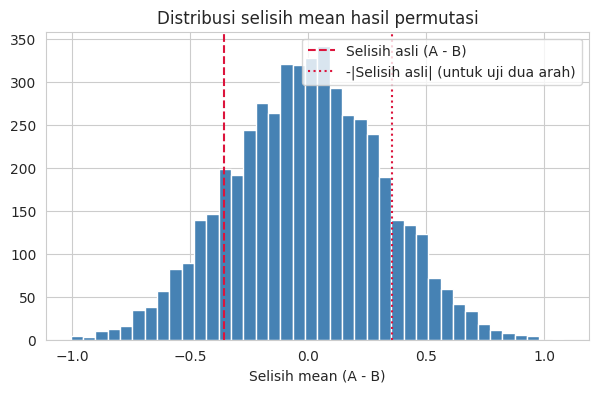

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(permuted_diffs, bins=40, color="steelblue", edgecolor="white")
ax.axvline(observed_diff, color="crimson", linestyle="--", label="Selisih asli (A - B)")
ax.axvline(-observed_diff, color="crimson", linestyle=":", label="-|Selisih asli| (untuk uji dua arah)")
ax.set_title("Distribusi selisih mean hasil permutasi")
ax.set_xlabel("Selisih mean (A - B)")
ax.legend()
plt.show()

## 4. Statistical Significance dan p-Values

**p-value** adalah proporsi hasil dari null model (misalnya distribusi hasil permutasi di atas) yang selisihnya sama ekstrem atau lebih ekstrem dibanding selisih yang benar-benar teramati. Makin kecil p-value, makin tidak masuk akal selisih itu terjadi murni karena kebetulan.

Sering dipakai ambang batas **alpha** (misalnya 0.05) sebagai batas "signifikan secara statistik", tapi buku ini mengingatkan bahwa ambang ini sebetulnya sembarang (arbitrary) dan tidak seharusnya diperlakukan sebagai batas mutlak benar/salah.

In [7]:
p_value = np.mean(np.abs(permuted_diffs) >= np.abs(observed_diff))
print(f"p-value (dua arah) dari permutation test: {p_value:.4f}")

alpha = 0.05
kesimpulan = "signifikan" if p_value < alpha else "tidak signifikan"
print(f"Pada alpha=0.05, hasil ini dianggap {kesimpulan}.")

p-value (dua arah) dari permutation test: 0.2708
Pada alpha=0.05, hasil ini dianggap tidak signifikan.


## 5. t-Tests

Untuk data numerik yang mendekati distribusi normal, kita tidak selalu perlu permutation test; ada rumus matematis langsung berdasarkan **distribusi-t** (lihat Bab 2), yaitu **t-test**. Hasilnya biasanya sangat mendekati hasil permutation test, tapi dihitung lebih cepat karena berbasis formula, bukan simulasi.

In [8]:
t_stat, p_value_ttest = stats.ttest_ind(time_a, time_b, equal_var=False)  # Welch's t-test

print(f"t-statistic : {t_stat:.3f}")
print(f"p-value     : {p_value_ttest:.4f}")
print(f"Degrees of freedom (Welch, otomatis dihitung scipy, tidak ditampilkan langsung)")

t-statistic : -1.098
p-value     : 0.2815
Degrees of freedom (Welch, otomatis dihitung scipy, tidak ditampilkan langsung)


Bandingkan p-value dari t-test ini dengan p-value dari permutation test sebelumnya, biasanya nilainya cukup dekat kalau asumsi normalitas datanya wajar.

## 6. Multiple Testing

Kalau kita menguji banyak hipotesis sekaligus (misalnya membandingkan puluhan variasi headline atau fitur), peluang menemukan sesuatu yang "signifikan" murni karena kebetulan ikut membesar. Ini disebut masalah **multiple testing** atau **multiple comparisons**.

Salah satu koreksi paling sederhana adalah **Bonferroni correction**: bagi ambang alpha dengan jumlah pengujian yang dilakukan, supaya makin banyak pengujian, makin ketat ambang yang dipakai untuk masing-masing.

In [9]:
alpha = 0.05
jumlah_pengujian = 20  # misal kita menguji 20 variasi sekaligus

alpha_terkoreksi = alpha / jumlah_pengujian
print(f"Alpha awal              : {alpha}")
print(f"Jumlah pengujian sekaligus: {jumlah_pengujian}")
print(f"Alpha setelah koreksi Bonferroni: {alpha_terkoreksi:.4f}")

Alpha awal              : 0.05
Jumlah pengujian sekaligus: 20
Alpha setelah koreksi Bonferroni: 0.0025


Dengan koreksi ini, sebuah hasil baru dianggap signifikan kalau p-value-nya di bawah 0.0025, bukan lagi 0.05. Ini membuat kita jauh lebih hati-hati sebelum menyimpulkan ada efek nyata, ketika sebenarnya kita sedang "mencoba banyak kemungkinan" sampai satu di antaranya kebetulan terlihat menarik.

## 7. Degrees of Freedom

**Degrees of freedom (df)** adalah jumlah nilai dalam suatu perhitungan yang bebas untuk berubah-ubah. Konsep ini muncul di banyak rumus statistik, termasuk t-test, chi-square, dan ANOVA, karena memengaruhi bentuk distribusi yang dipakai untuk menghitung p-value.

Contoh paling sederhana: kalau kita tahu mean dari n data, maka hanya n-1 dari nilai itu yang "bebas", nilai terakhir otomatis ditentukan supaya mean-nya sesuai. Karena itu variance sampel biasanya dihitung dengan membagi n-1, bukan n, supaya estimasinya tidak bias.

## 8. ANOVA

Kalau yang dibandingkan lebih dari dua kelompok sekaligus (misalnya Page 1, 2, 3, 4), memakai t-test berpasang-pasangan untuk tiap kombinasi akan membuka masalah multiple testing di atas. **ANOVA (Analysis of Variance)** menguji semua kelompok sekaligus: apakah variasi *antar* kelompok jauh lebih besar dibanding variasi *dalam* tiap kelompok, dibanding yang bisa dijelaskan kebetulan saja.

In [10]:
four_sessions = pd.read_csv(BASE + "four_sessions.csv")
four_sessions.head(8)

,Page,Time
0,Page 1,164
1,Page 2,178
2,Page 3,175
3,Page 4,155
4,Page 1,172
5,Page 2,191
6,Page 3,193
7,Page 4,166


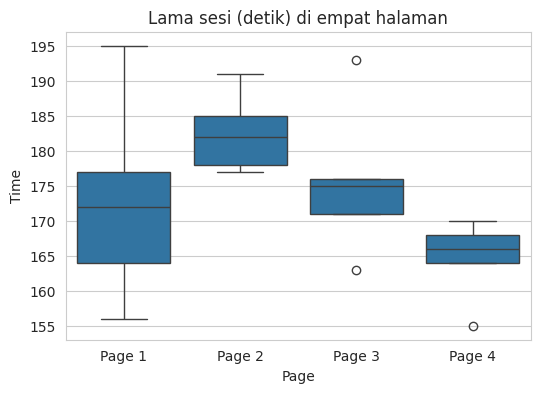

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=four_sessions, x="Page", y="Time", ax=ax)
ax.set_title("Lama sesi (detik) di empat halaman")
plt.show()

In [12]:
def anova_permutation_test(df, group_col, value_col, n_iterations=5000, random_state=None):
    rng_local = np.random.default_rng(random_state)
    groups = df[group_col].unique()
    group_size = df[group_col].value_counts().iloc[0]
    values = df[value_col].values

    observed_var = df.groupby(group_col)[value_col].mean().var()

    permuted_vars = np.empty(n_iterations)
    for i in range(n_iterations):
        shuffled = rng_local.permutation(values)
        group_means = [shuffled[j * group_size:(j + 1) * group_size].mean() for j in range(len(groups))]
        permuted_vars[i] = np.var(group_means)

    return observed_var, permuted_vars


observed_var, permuted_vars = anova_permutation_test(
    four_sessions, "Page", "Time", n_iterations=5000, random_state=42
)
p_value_anova_resampling = np.mean(permuted_vars >= observed_var)

print(f"Variance antar mean kelompok (asli) : {observed_var:.2f}")
print(f"p-value (resampling)                : {p_value_anova_resampling:.4f}")

Variance antar mean kelompok (asli) : 55.43
p-value (resampling)                : 0.0234


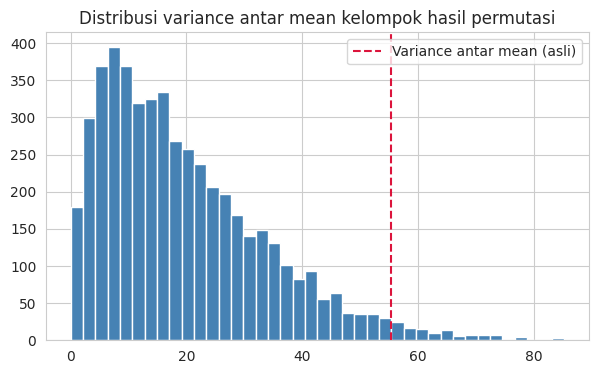

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(permuted_vars, bins=40, color="steelblue", edgecolor="white")
ax.axvline(observed_var, color="crimson", linestyle="--", label="Variance antar mean (asli)")
ax.set_title("Distribusi variance antar mean kelompok hasil permutasi")
ax.legend()
plt.show()

In [14]:
groups_data = [g["Time"].values for _, g in four_sessions.groupby("Page")]
f_stat, p_value_anova = stats.f_oneway(*groups_data)

print(f"F-statistic : {f_stat:.3f}")
print(f"p-value     : {p_value_anova:.4f}")

F-statistic : 2.740
p-value     : 0.0776


Keduanya sama-sama menguji apakah keempat halaman punya rata-rata lama sesi yang benar-benar berbeda, atau selisih yang terlihat di boxplot itu masih wajar sebagai variasi acak. Nilai p-value dari resampling dan dari F-distribution tidak selalu identik, apalagi dengan ukuran sampel sekecil ini (5 data per halaman), karena F-distribution mengasumsikan data normal sementara pendekatan resampling tidak memerlukan asumsi itu sama sekali. Kalau keduanya berbeda cukup jauh, itu justru sinyal bahwa asumsi normalitas di balik uji F patut dipertanyakan untuk data ini.

## 9. Chi-Square Test

Kalau ANOVA dipakai untuk data numerik dengan lebih dari dua kelompok, **chi-square test** dipakai untuk situasi serupa tapi pada data hitungan/kategori, misalnya membandingkan tingkat klik dari beberapa versi headline sekaligus. Uji ini membandingkan frekuensi yang **diamati** dengan frekuensi yang **diharapkan** seandainya tidak ada perbedaan nyata antar kelompok.

In [15]:
click_rates = pd.read_csv(BASE + "click_rates.csv")
click_rates

,Headline,Click,Rate
0,Headline A,Click,14
1,Headline A,No-click,986
2,Headline B,Click,8
3,Headline B,No-click,992
4,Headline C,Click,12
5,Headline C,No-click,988


In [16]:
contingency = click_rates.pivot(index="Headline", columns="Click", values="Rate")
contingency

Click,Click,No-click
Headline,,
Headline A,14,986
Headline B,8,992
Headline C,12,988


In [17]:
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency, correction=False)

print(f"Chi-square statistic : {chi2_stat:.3f}")
print(f"Degrees of freedom   : {dof}")
print(f"p-value              : {p_value_chi2:.4f}")
print("\nFrekuensi yang diharapkan (kalau tidak ada perbedaan antar headline):")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

Chi-square statistic : 1.666
Degrees of freedom   : 2
p-value              : 0.4348

Frekuensi yang diharapkan (kalau tidak ada perbedaan antar headline):
Click         Click  No-click
Headline                     
Headline A  11.3333  988.6667
Headline B  11.3333  988.6667
Headline C  11.3333  988.6667


Selain lewat rumus chi-square langsung, buku juga menunjukkan versi resampling-nya: acak ulang label headline pada data klik individual, hitung chi-square statistic-nya, ulangi ribuan kali, lalu bandingkan dengan chi-square asli. Cara ini bagus untuk memahami dari mana p-value chi-square sebenarnya berasal, walau untuk pemakaian sehari-hari fungsi `chi2_contingency` di atas sudah cukup.

## 10. Multi-Arm Bandit Algorithm

**Multi-arm bandit** adalah pendekatan alternatif dari A/B testing klasik, terinspirasi dari analogi mesin slot dengan beberapa tuas (arm), masing-masing punya peluang menang berbeda yang tidak kita ketahui di awal. Bedanya dengan A/B test klasik: alih-alih membagi trafik 50:50 terus-menerus sampai eksperimen selesai, algoritma ini **terus menyesuaikan** proporsi trafik ke arah opsi yang terlihat lebih baik, sambil tetap sesekali mencoba opsi lain (disebut trade-off antara *exploration* dan *exploitation*).

Salah satu algoritma paling sederhana adalah **epsilon-greedy**: dengan peluang epsilon, pilih arm secara acak (eksplorasi); selebihnya, pilih arm dengan performa terbaik sejauh ini (eksploitasi).

In [18]:
def epsilon_greedy_bandit(true_probs, n_rounds=2000, epsilon=0.1, random_state=None):
    rng_local = np.random.default_rng(random_state)
    n_arms = len(true_probs)
    counts = np.zeros(n_arms)
    wins = np.zeros(n_arms)

    for _ in range(n_rounds):
        if rng_local.random() < epsilon:
            arm = rng_local.integers(n_arms)  # eksplorasi
        else:
            with np.errstate(invalid="ignore"):
                est_rates = np.divide(wins, counts, out=np.zeros(n_arms), where=counts > 0)
            arm = np.argmax(est_rates)  # eksploitasi

        reward = rng_local.random() < true_probs[arm]
        counts[arm] += 1
        wins[arm] += reward

    return counts, wins

# Tiga arm dengan peluang menang sebenarnya berbeda (tidak diketahui algoritma)
true_probs = [0.20, 0.04, 0.08]  # mirip proporsi Arm A/B/C di buku
counts, wins = epsilon_greedy_bandit(true_probs, n_rounds=2000, epsilon=0.1, random_state=42)

hasil = pd.DataFrame({
    "arm": ["A", "B", "C"],
    "true_prob": true_probs,
    "jumlah_dicoba": counts,
    "estimasi_win_rate": wins / counts,
})
hasil

,arm,true_prob,jumlah_dicoba,estimasi_win_rate
0,A,0.20,1844.0,0.1979
1,B,0.04,74.0,0.0541
2,C,0.08,82.0,0.1098


Dari hasil ini biasanya terlihat arm dengan peluang menang sebenarnya lebih tinggi (Arm A) dicoba jauh lebih sering dibanding yang lain, karena algoritma dengan cepat "belajar" bahwa arm itu lebih menguntungkan, sambil tetap menyisakan sedikit eksplorasi ke arm lain lewat parameter epsilon.

## 11. Power and Sample Size

Sebelum menjalankan eksperimen, pertanyaan penting yang sering diabaikan: berapa banyak data yang dibutuhkan supaya hasil eksperimen bisa diandalkan? Dua konsep kuncinya:

- **Effect size**: seberapa besar perbedaan minimal yang ingin kita deteksi (misalnya kenaikan conversion rate dari 10% ke 11%).
- **Power**: peluang eksperimen berhasil mendeteksi efek tersebut kalau efek itu memang benar-benar ada, biasanya ditarget di angka 0.8 (80%).

Aturan umumnya: makin kecil effect size yang ingin dideteksi, makin besar sample size yang dibutuhkan. Buku menunjukkan lewat simulasi bahwa efek 10% dengan 300 sampel per kelompok sering kali tidak cukup untuk terdeteksi signifikan, sementara efek 50% dengan 2.000 sampel per kelompok jauh lebih mudah terdeteksi.

In [19]:
p1, p2 = 0.10, 0.11
effect_size = proportion_effectsize(p1, p2)

analysis = NormalIndPower()
n_dibutuhkan = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, alternative="two-sided")

print(f"Effect size (Cohen's h)         : {effect_size:.4f}")
print(f"Sample size dibutuhkan per grup  : {n_dibutuhkan:,.0f}")

Effect size (Cohen's h)         : -0.0326
Sample size dibutuhkan per grup  : 14,744


In [20]:
p1, p2 = 0.10, 0.15
effect_size_besar = proportion_effectsize(p1, p2)
n_dibutuhkan_besar = analysis.solve_power(effect_size=effect_size_besar, alpha=0.05, power=0.8, alternative="two-sided")

print(f"Effect size (10% -> 15%)         : {effect_size_besar:.4f}")
print(f"Sample size dibutuhkan per grup   : {n_dibutuhkan_besar:,.0f}")

Effect size (10% -> 15%)         : -0.1519
Sample size dibutuhkan per grup   : 680


Terlihat jelas: mendeteksi kenaikan kecil (10% ke 11%) butuh sampel jauh lebih besar dibanding mendeteksi kenaikan besar (10% ke 15%). Ini alasan kenapa eksperimen yang mengejar efek sangat kecil butuh trafik/data yang jauh lebih banyak dan waktu yang jauh lebih lama untuk memberi hasil yang bisa diandalkan.

## Poin-poin Penting Bab 3

- A/B test yang baik mensyaratkan randomisasi subjek ke tiap kelompok, dan metrik keberhasilan yang ditentukan sebelum eksperimen berjalan.
- Permutation test adalah cara intuitif menguji signifikansi: acak ulang label kelompok berkali-kali, lalu bandingkan hasil asli terhadap distribusi hasil acakan itu.
- p-value mengukur seberapa mungkin selisih yang teramati terjadi murni karena kebetulan, bukan bukti langsung "seberapa penting" efeknya.
- Multiple testing membesarkan peluang menemukan hasil "signifikan" palsu; perlu koreksi seperti Bonferroni kalau menguji banyak hipotesis sekaligus.
- ANOVA memperluas ide t-test untuk membandingkan lebih dari dua kelompok sekaligus, sementara chi-square test dipakai untuk data kategorikal/hitungan.
- Multi-arm bandit jadi alternatif A/B testing klasik yang lebih adaptif, mengurangi trafik yang "terbuang" ke opsi yang jelas lebih buruk selama eksperimen berjalan.
- Power dan sample size perlu dihitung di awal, supaya eksperimen tidak berakhir inconclusive hanya karena datanya kurang banyak untuk mendeteksi efek sekecil yang ditargetkan.

Referensi: Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists*, 2nd Edition, Bab 3 "Statistical Experiments and Significance Testing". O'Reilly Media. Dataset: repo data resmi buku di GitHub (gedeck/practical-statistics-for-data-scientists).